### Introducción

Este notebook tendrá como finalidad presentar el entrenamiento de los modelos de regresión logística, árbol de decisión y random forest

### Importación de librerías

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)


### Definición de constantes

In [3]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DIRECTORIO_DATOS_MODELADOS = f"{PATH_DIRECTORIO_DATOS}/processed"

In [4]:
PATH_DATASET_MODELADOS = f"{PATH_DIRECTORIO_DATOS_MODELADOS}/dataset_practica_final_modelado.csv"

### Lectura de datos

In [5]:
df_reservas= pd.read_csv(PATH_DATASET_MODELADOS) 

In [6]:
df_reservas

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,...,adr,required_car_parking_spaces,total_of_special_requests,adults_categories,has_children,has_babies,arrival_season,month_period,arrival_quarter,country_grouped
0,Resort Hotel,0,342,0,0,BB,Direct,Direct,0,0,...,0.00,0,0,2 adultos,0,0,temporada_alta,inicio_mes,Q3,PRT
1,Resort Hotel,0,737,0,0,BB,Direct,Direct,0,0,...,0.00,0,0,2 adultos,0,0,temporada_alta,inicio_mes,Q3,PRT
2,Resort Hotel,0,7,0,1,BB,Direct,Direct,0,0,...,75.00,0,0,1 adulto,0,0,temporada_alta,inicio_mes,Q3,GBR
3,Resort Hotel,0,13,0,1,BB,Corporate,Corporate,0,0,...,75.00,0,0,1 adulto,0,0,temporada_alta,inicio_mes,Q3,GBR
4,Resort Hotel,0,14,0,2,BB,Online TA,TA/TO,0,0,...,98.00,0,1,2 adultos,0,0,temporada_alta,inicio_mes,Q3,GBR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118892,City Hotel,0,23,2,5,BB,Offline TA/TO,TA/TO,0,0,...,96.14,0,0,2 adultos,0,0,temporada_alta,fin_mes,Q3,BEL
118893,City Hotel,0,102,2,5,BB,Online TA,TA/TO,0,0,...,225.43,0,2,3 o más adultos,0,0,temporada_alta,fin_mes,Q3,FRA
118894,City Hotel,0,34,2,5,BB,Online TA,TA/TO,0,0,...,157.71,0,4,2 adultos,0,0,temporada_alta,fin_mes,Q3,DEU
118895,City Hotel,0,109,2,5,BB,Online TA,TA/TO,0,0,...,104.40,0,0,2 adultos,0,0,temporada_alta,fin_mes,Q3,GBR


### Regresión Logística

#### Creación del modelo y ajuste

Hacemos la preparación de los conjuntos de datos para las variables independientes y la variable objetivo. De esta forma podemos hacer el train test split.

In [7]:
# Separando las variables

X_reservas = df_reservas.drop(columns='is_canceled')
y_reservas = df_reservas['is_canceled']

In [8]:
# Realizando train test split con la opción stratify para que la proporción de clases se mantenga en los conjuntos train y test

X_train, X_test, y_train, y_test = train_test_split(X_reservas, y_reservas, test_size=0.2, random_state=42, stratify=y_reservas)



Procedemos a realzar el one hot encoding con las columnas categóricas para poder realizar el entrenamiento del modelo de regresión logística.


In [9]:
columnas_categoricas = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'adults_categories', 'arrival_season', 'month_period', 'arrival_quarter', 'country_grouped']

preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), columnas_categoricas)
    ],
    remainder='passthrough'
)

X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

Se realiza el escalamiento ya que la regresión logística es sensible a las diferencias entre escalas

In [10]:
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train_procesado)
X_test_escalado = escalador.transform(X_test_procesado)

Entrenamos un modelo de regresión logística usando GridSearchCV para encontrar los mejores hiperparámetros

In [11]:
rl_parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [100, 200, 500, 1000]
}

modelo_rl = LogisticRegression(random_state=42)
modelo_rl_cv = GridSearchCV(modelo_rl, rl_parametros, cv=5, scoring='f1')
modelo_rl_cv.fit(X_train_escalado, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'max_iter': [100, 200, 500, 1000],
                         'solver': ['liblinear']},
             scoring='f1')

#### Evaluación del modelo

In [12]:
# Imprimimos los parámetros que eligió como ganadores
print("Parámetros ganadores:", modelo_rl_cv.best_params_)

# Usamos el modelo ganador sobre los datos de prueba (Test)
y_pred = modelo_rl_cv.predict(X_test_escalado)

# Reporte de métricas
print("\n--- REPORTE DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

Parámetros ganadores: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}

--- REPORTE DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     14949
           1       0.81      0.66      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



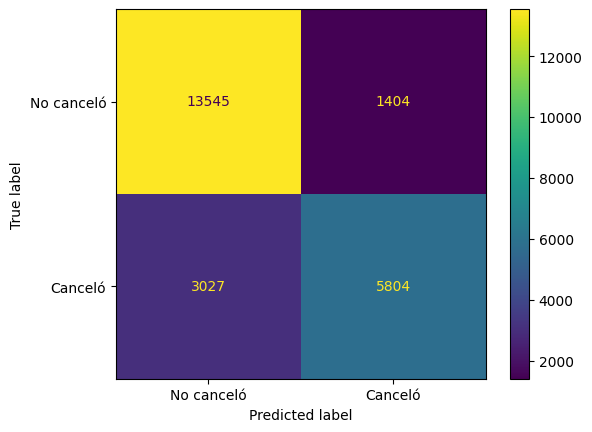

In [13]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No canceló', 'Canceló'])
disp.plot()
plt.show()

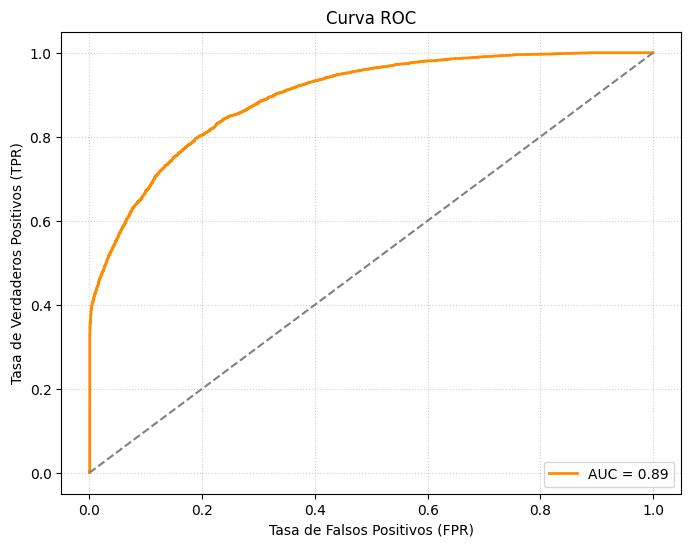

In [14]:
# Curva ROC

y_proba = modelo_rl_cv.predict_proba(X_test_escalado)[:, 1]

auc = roc_auc_score(y_test, y_proba)


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Árbol de Decisión

#### Creación del modelo y ajuste

Procedemos a realizar el entrenamiento del modelo basándonos en las variables X_train y X_test que ya tenemos separadas y procesadas. Entrenamos ek árbol de decisión usando GridSearchCV para encontrar los mejores hiperparámetros

In [15]:
modelo_dt = DecisionTreeClassifier(random_state=42)

dt_parametros = {
    'max_depth': [2, 3, 5, 7, 10, 20, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8]
}

modelo_arbol_cv = GridSearchCV(modelo_dt, dt_parametros, cv=5, scoring='f1')
modelo_arbol_cv.fit(X_train_escalado, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 7, 10, 20, None],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 20, 50]},
             scoring='f1')